In [34]:
import numpy as np
import pandas as pd

import torch
from torch.utils.data import DataLoader
from torchinfo import summary

from matplotlib import rcParams
from matplotlib.patches import Circle

import h5py
import scipy.stats
from scipy.stats import median_abs_deviation

import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams["font.sans-serif"] = ["IBM Plex Sans"]

# Construct variants training and validation datasets

In [2]:
variants = pd.read_parquet(
    "/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v4/output/non_aggregated.all.parquet"
)

In [3]:
variants["total_counts"] = variants.ref_counts + variants.alt_counts

passed_read_count = variants.total_counts > 30
signif = (variants.FDR_sample < 0.1) & (variants.logit_es.abs() < 6)
neg = variants.FDR_sample > 0.5

positives = variants[passed_read_count & signif]
negatives = variants[passed_read_count & neg].sample(n=len(positives))

examples = pd.concat([positives, negatives])

In [ ]:
bins = np.linspace(-5, 5, 100)
h = plt.hist(positives.logit_es, bins=bins)
h = plt.hist(negatives.logit_es, bins=bins, color="red", alpha=0.3)
plt.xlabel("LFC variant effect")

### Sample training and validation samples

In [6]:
columns = [
    "#chr",
    "start",
    "ref",
    "alt",
    "ref_counts",
    "total_counts",
    "BAD",
    "logit_es",
    "sample_id",
    "FDR_sample",
]

dataset = examples[columns].rename(columns={"#chr": "chrom", "start": "pos"})

train_df = dataset.sample(frac=0.9, random_state=1)
valid_df = dataset.drop(train_df.index)

train_df.shape, valid_df.shape

((589905, 10), (65545, 10))

### Write datasets to H5 files

In [2]:
def df_to_h5(path, df: pd.DataFrame):
    with h5py.File(path, "w") as f:
        for column in df.columns:
            data = df[column].values

            if pd.api.types.is_object_dtype(df[column]) or pd.api.types.is_string_dtype(
                df[column]
            ):
                data = data.astype("S30")  # fixed-length byte strings

            f.create_dataset(column, data=data)


## loading df from h5
def df_from_h5(path):
    with h5py.File(path, "r") as f:
        data = {}
        for key in f.keys():
            arr = f[key][:]
            # Decode byte strings if needed
            if arr.dtype.kind == "S":
                arr = arr.astype(str)
            data[key] = arr
        return pd.DataFrame(data)

In [8]:
df_to_h5("/home/jvierstra/proj/vinson/data/dnase-cavs.v4.train.h5", train_df)
df_to_h5("/home/jvierstra/proj/vinson/data/dnase-cavs.v4.val.h5", valid_df)

# Testing, dataloader, model & loss function

In [2]:
from vinson.dataset import VariantEmbeddingDataset
from vinson.loss import binomial_mixture_loss, binomial_mixture_nll
from vinson.model import BassetTrunkEmbed, CellEmbedding, VinsonVariantEmbedModel

# Create model
embed = CellEmbedding(n_inputs=637, n_layers=1)
trunk = BassetTrunkEmbed(embed)
model = VinsonVariantEmbedModel(trunk)

### Load in dataset and dataloader

In [3]:
examples_file = "/home/jvierstra/proj/vinson/data/dnase-cavs.v4.val.h5"

embeddings_file = "/home/jvierstra/proj/vinson/data/embeddings.tsv"
read_depth_file = "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/JUL10//continious_annotation/total_cutcounts.tsv"

fasta_file = "/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa"

dataset = VariantEmbeddingDataset(
    examples_file,
    embeddings_file,
    fasta_file,
    reverse_complement=True,
    jitter=0,
    noise=0,
)

dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=1,
    pin_memory=True,
    drop_last=True,
)

Opening samples file...
Loading embeddings...
Done!


### Explore loss function

In [31]:
# Select a variant
variant = dataset[340]

# Read counts over variant
total_counts = torch.tensor(variant["total_counts"])
ref_counts = torch.tensor(variant["ref_counts"])
bad_score = torch.tensor(variant["bad_score"])  # BAD score
#tau = torch.tensor(0.5 * np.log(2))
tau = -1 # removes prior

# Observed log-fold change
lfc = torch.log(ref_counts / (total_counts - ref_counts))

# Cycle through LFC values to simulate gradient search
pred_lfc_logit = torch.linspace(-10, 10, 10_000)

nll = binomial_mixture_loss(
    pred_lfc_logit, 
    ref_counts,
    total_counts,
    bad_score,
    tau=tau, 
    reduction="none"
)

print(f"ref_counts = {ref_counts}")
print(f"total_counts = {total_counts}")
print(f"bad = {bad_score}")
print(f"tau = {tau}")
print(f"lfc min nll = {pred_lfc_logit[nll.argmin()]}")
print(f"lfc raw = {lfc}")

ref_counts = 43
total_counts = 52
bad = 1.5
tau = -1
lfc min nll = 1.847184419631958
lfc raw = 1.5639755725860596


Text(0.5, 1.0, 'Loss landscape for a single variant')

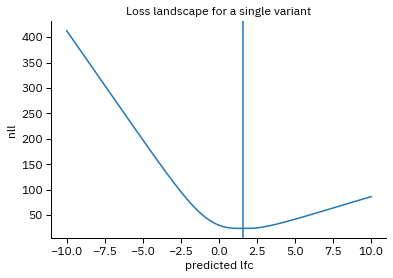

In [32]:
plt.plot(pred_lfc_logit, nll)
plt.axvline(lfc)

plt.xlabel("predicted lfc")
plt.ylabel("nll")

plt.title("Loss landscape for a single variant")

# Train model

To train model edit and run the following script: ```sbatch train_variants.sh```

# Analyze, predict & interpret model

### Load in trunk pre-trained from the DHS model

In [6]:
pretrained_state_dict = torch.load(
    "models/regression_data_JUL10.batch1_v3_poisson/checkpoints/last.ckpt",
    map_location=torch.device("cpu"),
)["state_dict"]

trunk_pretrained = {k: v for k, v in pretrained_state_dict.items() if "trunk." in k}

### Load in pre-trained variant model

In [44]:
pretrained_state_dict = torch.load(
    "models/variant_v2/checkpoints/last.ckpt",
    map_location=torch.device("cpu"),
)["state_dict"]

In [45]:
model_dict = model.state_dict()
model_dict.update(pretrained_state_dict)

model.load_state_dict(model_dict, strict=False)

_ = model.eval()

torch.set_grad_enabled(False)

### Predict variants (random batch)

In [49]:
batch = next(iter(dataloader))

X_seq_ref, X_seq_alt, X_embed, ref_counts, total_counts, bad_score = (
    batch["seq_ref"],
    batch["seq_alt"],
    batch["embed"],
    batch["ref_counts"],
    batch["total_counts"],
    batch["bad_score"],
)

# Estimated log-fold change
lfc = (ref_counts / (total_counts - ref_counts)).log()

# Predict example with model
y = model(X_seq_ref, X_seq_alt, X_embed).squeeze()

# Can evaluate different tau values -- -1 removes prior
tau = 0.5 * torch.tensor(2).log()
tau = -1

# Compute loss
loss = binomial_mixture_loss(
    y, ref_counts, total_counts, bad_score, tau=tau, reduction="none"
)

print(f"loss = {loss.mean()}")

loss = 51.714780825269635


Text(0.5, 1.0, 'Loss landscape for batch')

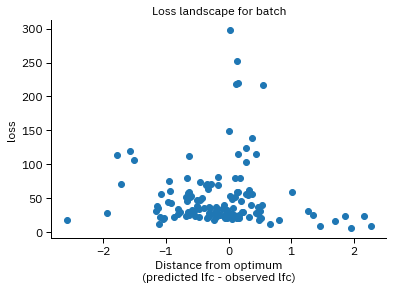

In [50]:
plt.scatter(y.detach() - lfc, loss.detach())
plt.xlabel("Distance from optimum\n(predicted lfc - observed lfc)")
plt.ylabel("loss")

plt.title("Loss landscape for batch")

### Plot the predicted vs. observed LFC 

Text(0.5, 1.0, 'Variant effect prediction from DNA sequence')

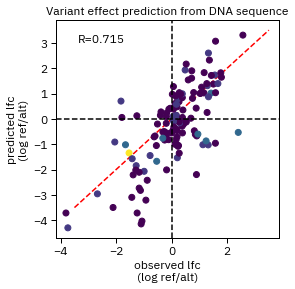

In [51]:
m, b = np.polyfit(lfc, y.detach(), 1)
pearsonr = scipy.stats.pearsonr(lfc, y.detach())

plt.scatter(lfc, y.detach() * 1 / m + b, c=bad_score)
# plt.scatter(lfc, y.detach(), c=bad_score)


plt.axvline(0, ls="--", color="k")
plt.axhline(0, ls="--", color="k")


plt.plot([-3.5, 3.5], [-3.5, 3.5], color="red", ls="--", zorder=-1)

# plt.xlim(-4.5, 4.5)
# plt.ylim(-4.5, 4.5)

[plt.gca().spines[loc].set_visible(True) for loc in ["top", "right"]]

t = plt.text(
    0.1,
    0.9,
    f"R={pearsonr.statistic:0.3f}",
    fontdict=dict(fontsize="large"),
    transform=plt.gca().transAxes,
)

# c = Circle((0,0), 1, fc="lightgrey", alpha=0.75)
# plt.gca().add_patch(c)

plt.gcf().set_size_inches(4, 4)

plt.xlabel("observed lfc\n(log ref/alt)")
plt.ylabel("predicted lfc\n(log ref/alt)")

plt.title("Variant effect prediction from DNA sequence")